##1. Persiapan Dataset (Loading Data)

Langkah pertama dimulai dengan mengimpor library yang diperlukan seperti pandas, numpy, matplotlib, dan sklearn. Dataset `data_training.csv` dimuat untuk proses pembangunan model, sedangkan `data_testing.csv` digunakan untuk prediksi akhir.

In [385]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Load data_training.csv into a DataFrame
df_train = pd.read_csv('/content/data_training.csv')

# Display the first 5 rows of the training data
print("Training Data (df_train):")
display(df_train.head())

Training Data (df_train):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [386]:
# Load data_testing.csv into a DataFrame
df_test = pd.read_csv('/content/data_testing.csv')

# Display the first 5 rows of the testing data
print("\nTesting Data (df_test):")
display(df_test.head())


Testing Data (df_test):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


Setelah memuat dataset, kita dapat melihat beberapa baris pertama dari data pelatihan (`df_train`) dan pengujian (`df_test`). Pemeriksaan awal ini membantu mengonfirmasi bahwa data telah dimuat dengan benar dan memberikan gambaran sekilas tentang struktur dan kolomnya.

## 2. Pengecekan Missing Value
Dilakukan pemeriksaan untuk memastikan tidak ada data yang kosong pada dataset. Berdasarkan pengecekan menggunakan fungsi `.isnull().sum()`, tidak ditemukan nilai yang hilang pada setiap kolom fitur kimiawi. Hal ini menunjukkan bahwa data cukup bersih dan tidak memerlukan tahap imputasi (pengisian nilai kosong).

In [387]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Output `df_train.info()` memberikan ringkasan DataFrame, termasuk jumlah entri, jumlah kolom, tipe data untuk setiap kolom, dan jumlah nilai non-null. Langkah ini penting untuk memahami tipe data dan dengan cepat mengidentifikasi apakah ada kolom yang memiliki nilai yang hilang. Dalam kasus ini, semua kolom menunjukkan 857 entri non-null dari 857 total entri, menunjukkan tidak ada nilai yang hilang dalam set pelatihan.

In [388]:
print("Missing values in Training Data (df_train):")
display(df_train.isnull().sum())

print("\nMissing values in Testing Data (df_test):")
display(df_test.isnull().sum())

Missing values in Training Data (df_train):


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Missing values in Testing Data (df_test):


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Pengecekan ini secara eksplisit mengkonfirmasi tidak adanya nilai yang hilang di dataset pelatihan (`df_train`) dan pengujian (`df_test`). Output `0` untuk semua kolom berarti bahwa tidak ada imputasi data atau penanganan nilai yang hilang yang diperlukan, membuat dataset siap untuk pemrosesan lebih lanjut.

## 3. Analisis Data Eksplorasi (EDA)
Tahap ini bertujuan untuk memahami distribusi data dan hubungan antar variabel. Fokus utama adalah melihat bagaimana fitur seperti `alcohol`, `volatile acidity`, dan `sulphates` berkorelasi dengan variabel target `quality`. Visualisasi seperti heatmap korelasi dapat membantu menentukan fitur mana yang paling berpengaruh.

In [389]:
# Calculate the correlation matrix
correlation_matrix = df_train.corr()

# Display the correlation matrix with 'quality'
print("Correlation matrix with 'quality':")
display(correlation_matrix['quality'].sort_values(ascending=False))

Correlation matrix with 'quality':


,quality
quality,1.000000
alcohol,0.473555
sulphates,0.260703
citric acid,0.221263
fixed acidity,0.092714
Id,0.049030
residual sugar,-0.020511
pH,-0.033199
free sulfur dioxide,-0.054509
chlorides,-0.144946


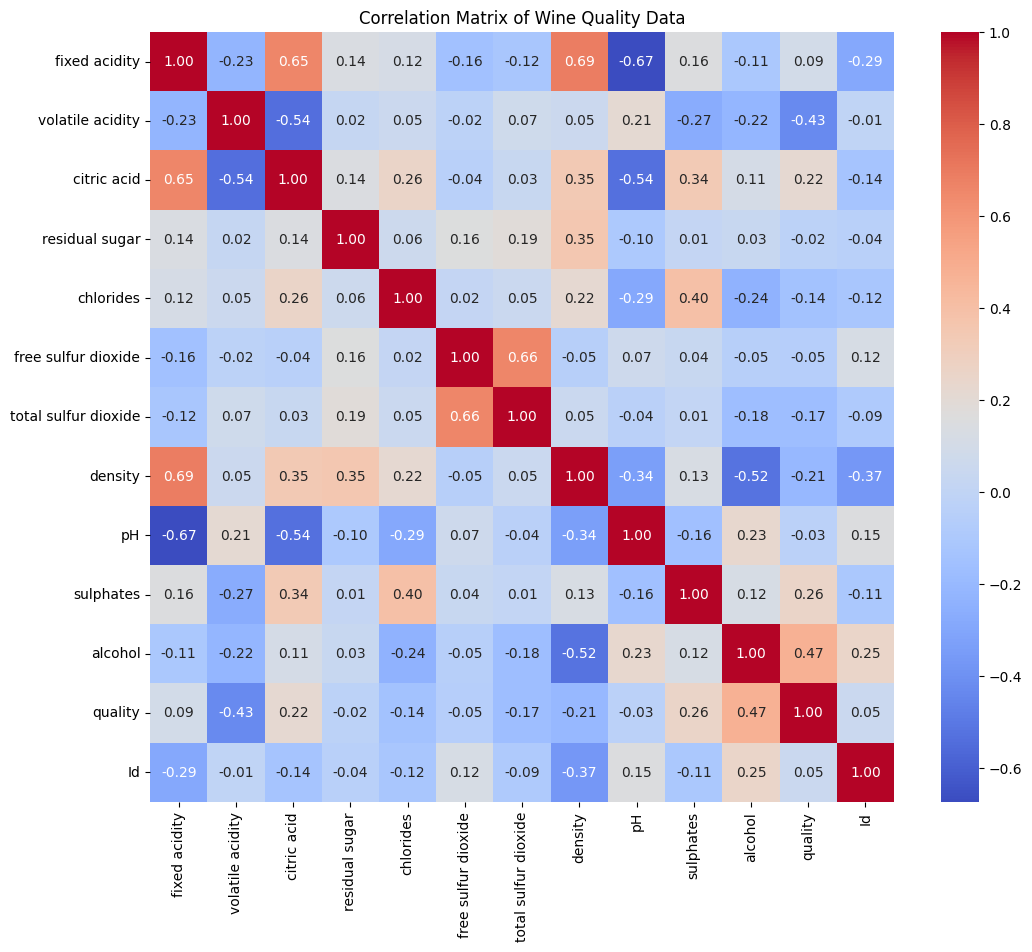

In [390]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Wine Quality Data')
plt.show()

In [391]:
# Correlation of specific features with 'quality'
print("Correlation of 'alcohol' with 'quality':", correlation_matrix.loc['alcohol', 'quality'])
print("Correlation of 'volatile acidity' with 'quality':", correlation_matrix.loc['volatile acidity', 'quality'])
print("Correlation of 'sulphates' with 'quality':", correlation_matrix.loc['sulphates', 'quality'])

Correlation of 'alcohol' with 'quality': 0.473554609708634
Correlation of 'volatile acidity' with 'quality': -0.43005867190527175
Correlation of 'sulphates' with 'quality': 0.2607027330719354


Bagian Analisis Data Eksplorasi (EDA) pertama-tama menghitung matriks korelasi untuk semua fitur dan secara spesifik menampilkan korelasi setiap fitur dengan variabel target 'quality'. Heatmap secara visual merepresentasikan korelasi ini, menunjukkan kekuatan dan arah hubungan. Nilai positif (warna lebih hangat) menunjukkan korelasi positif (misalnya, kadar alkohol yang lebih tinggi sering berkorelasi dengan kualitas yang lebih tinggi), sementara nilai negatif (warna lebih dingin) menunjukkan korelasi negatif (misalnya, keasaman volatil yang lebih tinggi sering berkorelasi dengan kualitas yang lebih rendah). Nilai korelasi individu untuk 'alcohol', 'volatile acidity', dan 'sulphates' dengan 'quality' kemudian dicetak, mengkonfirmasi pengaruh masing-masing terhadap kualitas anggur.

## 4. Pemisahan Fitur dan Target

Fitur-fitur kimiawi dipisahkan dari target prediksi. Variabel dependen adalah kolom quality, sedangkan variabel independen adalah seluruh kolom fitur kimiawi. Kolom Id dihapus dari data latih karena merupakan identitas unik yang tidak memiliki pengaruh ilmiah terhadap kualitas anggur.

In [392]:
# Separate features (X) and target (y) for the training data
X_train = df_train.drop(columns=['quality', 'Id'])
y_train = df_train['quality']

# Prepare features for the testing data (drop 'Id' if present, 'quality' is not in test data)
X_test = df_test.drop(columns=['Id'])

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)

display(X_train.head())
display(y_train.head())
display(X_test.head())

Shape of X_train: (857, 11)
Shape of y_train: (857,)
Shape of X_test: (286, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0


,quality
0,5
1,5
2,7
3,6
4,6


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000


Pada langkah ini, dataset dibagi menjadi fitur (`X`) dan variabel target (`y`). Untuk data pelatihan, 'quality' ditetapkan sebagai variabel target, dan 'Id' dihapus dari fitur karena merupakan pengidentifikasi dan bukan fitur prediktif. Demikian pula, 'Id' dihapus dari fitur pengujian (`X_test`). Bentuk DataFrame yang dihasilkan (`X_train`, `y_train`, `X_test`) dicetak untuk mengkonfirmasi dimensi, dan `.head()` masing-masing ditampilkan untuk verifikasi cepat pemisahan.

## 5. Pembagian Data (Train-Test Split)

Dataset `data_training.csv` dibagi menjadi dua bagian:

*   **Data Train (80%)**: Digunakan untuk melatih algoritma agar dapat mengenali pola data.

*   **Data Validation (20%)**: Digunakan untuk menguji performa model secara internal sebelum diterapkan pada data testing yang sebenarnya. Proses ini penting untuk mendeteksi adanya _overfitting_.

In [393]:
# Split the training data into training and validation sets (80% train, 20% validation)
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print("Shape of X_train_split:", X_train_split.shape)
print("Shape of y_train_split:", y_train_split.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train_split: (685, 11)
Shape of y_train_split: (685,)
Shape of X_val: (172, 11)
Shape of y_val: (172,)


Fungsi `train_test_split` digunakan untuk membagi data `X_train` dan `y_train` menjadi set pelatihan (`X_train_split`, `y_train_split`) dan validasi (`X_val`, `y_val`). `test_size` sebesar 0.2 berarti 20% data dialokasikan untuk validasi, dan `random_state=42` memastikan reproduktibilitas. Pembagian ini sangat penting untuk mengevaluasi kinerja model pada data yang belum terlihat sebelum mengujinya pada set `df_test` akhir, membantu mendeteksi *overfitting*.

In [394]:
print("X_train_split head:")
display(X_train_split.head())

print("y_train_split head:")
display(y_train_split.head())

print("X_val head:")
display(X_val.head())

print("y_val head:")
display(y_val.head())

X_train_split head:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
177,9.0,0.785,0.24,1.70,0.078,10.0,21.0,0.99692,3.29,0.67,10.0
505,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9
17,7.7,0.490,0.26,1.90,0.062,9.0,31.0,0.99660,3.39,0.64,9.6
738,8.0,0.380,0.44,1.90,0.098,6.0,15.0,0.99560,3.30,0.64,11.4
236,7.4,0.580,0.00,2.00,0.064,7.0,11.0,0.99562,3.45,0.58,11.3


y_train_split head:


,quality
177,5
505,5
17,5
738,6
236,6


X_val head:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
492,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.100000
65,7.7,0.490,0.26,1.9,0.062,9.0,31.0,0.99660,3.39,0.64,9.600000
110,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.400000
569,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.500000
625,5.3,0.470,0.11,2.2,0.048,16.0,89.0,0.99182,3.54,0.88,13.566667


y_val head:


,quality
492,5
65,5
110,5
569,5
625,7


In [395]:
print("Jumlah setiap kelas kualitas di y_train_split:")
display(y_train_split.value_counts().sort_index())

Jumlah setiap kelas kualitas di y_train_split:


,count
quality,
3,5
4,21
5,289
6,273
7,87
8,10


Dari angka-angka ini, terlihat jelas adanya ketidakseimbangan kelas (imbalanced class). Kelas 5 dan 6 adalah kelas mayoritas, sementara kelas 3, 4, dan 8 adalah kelas minoritas dengan jumlah sampel yang sangat sedikit. Hal ini penting untuk dipertimbangkan dalam pengembangan model karena model cenderung bias terhadap kelas mayoritas.

## 6. Feature Scaling

Karena fitur kimiawi memiliki rentang nilai yang sangat berbeda (misalnya `density` yang mendekati angka 1, sementara `total sulfur dioxide` mencapai angka puluhan atau ratusan), maka dilakukan **Standardization** menggunakan `StandardScaler`. Langkah ini memastikan semua fitur berada pada skala yang sama sehingga model dapat belajar dengan lebih stabil dan cepat.

In [396]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data (X_train_split) and transform it
X_train_scaled = scaler.fit_transform(X_train_split)

# Transform the validation and test data using the *same* scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier inspection and to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_split.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("First 5 rows of X_train_scaled:")
display(X_train_scaled.head())
print("First 5 rows of X_val_scaled:")
display(X_val_scaled.head())
print("First 5 rows of X_test_scaled:")
display(X_test_scaled.head())

First 5 rows of X_train_scaled:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.434650,1.433978,-0.146214,-0.640901,-0.172558,-0.571978,-0.787661,0.142301,-0.157984,0.117584,-0.398729
1,-0.620733,1.101689,-1.132212,1.767245,0.010029,-1.145491,-1.095174,-0.237517,0.648118,-1.659612,0.444166
2,-0.327571,-0.199778,-0.042425,-0.477637,-0.537733,-0.667563,-0.480147,-0.026507,0.513768,-0.072830,-0.773348
3,-0.151674,-0.808975,0.891679,-0.477637,0.283910,-0.954320,-0.972169,-0.554032,-0.090809,-0.072830,0.912441
4,-0.503468,0.298656,-1.391685,-0.396005,-0.492086,-0.858734,-1.095174,-0.543481,0.916819,-0.453658,0.818786


First 5 rows of X_val_scaled:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.620733,0.935544,-0.717055,-0.396005,-0.218205,-0.380807,-0.818412,-0.627885,-0.157984,-0.707543,-0.305074
1,-0.327571,-0.199778,-0.042425,-0.477637,-0.537733,-0.667563,-0.480147,-0.026507,0.513768,-0.072830,-0.773348
2,-0.503468,0.741708,-1.391685,-0.559269,-0.241029,-0.285221,-0.203385,0.606522,1.319870,-0.580600,-0.960658
3,-1.324321,-0.144396,-1.391685,-0.885797,-0.651850,-0.094051,-0.633904,-1.144859,0.312242,-1.278784,-0.867003
4,-1.734747,-0.310541,-0.820844,-0.232741,-0.857261,0.001535,1.303431,-2.548074,1.521396,1.450481,2.941631


First 5 rows of X_test_scaled:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.855262,0.464801,-1.184107,-0.804165,-0.651850,-1.049905,-1.125926,-0.738665,0.715294,-0.326715,-0.867003
1,-0.796630,1.738576,-0.301898,1.318268,-0.263852,0.001535,0.565398,0.933587,1.454221,0.434940,-1.116750
2,-0.737997,0.298656,-0.768950,-0.477637,0.124146,1.722074,2.379728,-0.554032,0.849644,-1.088370,0.069546
3,-0.268938,-0.255159,2.137150,-0.640901,7.518933,-0.189636,-0.449396,-0.047608,-1.501489,2.592964,-1.241623
4,2.486782,0.409419,1.151152,1.481532,0.329557,-1.049905,-1.002920,2.294600,-0.426685,0.561883,1.380716


Penskalaan fitur dilakukan menggunakan `StandardScaler`. Proses ini mengubah fitur sehingga memiliki mean 0 dan standar deviasi 1. Hal ini penting karena fitur-fitur seperti 'density' dan 'total sulfur dioxide' memiliki rentang yang sangat berbeda, dan banyak algoritma *machine learning* berkinerja lebih baik ketika fitur berada pada skala yang serupa. Scaler di-*fit* pada data pelatihan (`X_train_split`) dan kemudian digunakan untuk *transform* data pelatihan, validasi, dan pengujian. Data yang diskala diubah kembali menjadi DataFrame, dan 5 baris pertama ditampilkan untuk menunjukkan efek penskalaan.

### Model Random Forest

Untuk membangun model yang stabil dan mencegah *overfitting*, saya akan menggunakan `RandomForestClassifier` dengan penyesuaian hyperparameter berikut:

*   `n_estimators = 500`: Meningkatkan jumlah pohon dalam hutan untuk mengurangi varians dan meningkatkan stabilitas model.
*   `max_depth = 15`: Menetapkan kedalaman maksimum untuk setiap pohon, mencegahnya tumbuh terlalu dalam dan menghafal data pelatihan.
*   `min_samples_leaf = 2`: Membutuhkan minimal 2 sampel di setiap daun, membantu mengurangi *overfitting*.

Parameter lainnya (`min_samples_split`, `random_state`, `class_weight`, `n_jobs`) akan dipertahankan.

In [407]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=500,  # Increased from 300
    max_depth=15,      # Set a finite max_depth to prevent overfitting
    min_samples_split=2,
    min_samples_leaf=2,  # Added min_samples_leaf to prevent overfitting
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train the model using the scaled training data
rf_model.fit(X_train_scaled, y_train_split)

print("Random Forest Classifier Model berhasil dilatih!")

Random Forest Classifier Model berhasil dilatih!


## 8. Evaluasi Model

Model yang telah dilatih kemudian diuji menggunakan data validasi. Metrik evaluasi yang digunakan mencakup:

*   Accuracy Score: Untuk melihat persentase prediksi yang benar secara keseluruhan
*   Confusion Matrix: Untuk melihat detail prediksi yang benar dan salah pada setiap kategori kualitas.

In [411]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict on the validation set using the classifier
y_pred_val_class = rf_model.predict(X_val_scaled)

# Calculate Accuracy Score
accuracy_val_class = accuracy_score(y_val, y_pred_val_class)

# Calculate Confusion Matrix
conf_matrix_val_class = confusion_matrix(y_val, y_pred_val_class)

print(f"\nEvaluasi Model Random Forest Classifier pada Set Validasi:")
print(f"Skor Akurasi: {accuracy_val_class:.4f}")
print(f"\nMatriks Kebingungan:\n{conf_matrix_val_class}")


Evaluasi Model Random Forest Classifier pada Set Validasi:
Skor Akurasi: 0.6105

Matriks Kebingungan:
[[ 0  0  0  1  0  0]
 [ 1  0  4  0  0  0]
 [ 1  1 55 15  1  0]
 [ 0  0 20 42  6  0]
 [ 0  0  0 15  7  0]
 [ 0  0  0  0  2  1]]


##9. Prediksi Data Testing Final

Model final digunakan untuk memprediksi nilai quality pada file data_testing.csv. Sebelum diprediksi, data testing juga diproses dengan scaler yang sama agar format fiturnya konsisten dengan data saat pelatihan.

In [414]:
# Predict on the test data using the classifier
y_pred_test_class = rf_model.predict(X_test_scaled)

# Add the predictions to df_test in a new column for comparison
df_test['quality_prediction'] = y_pred_test_class

df_test = df_test.drop(columns=['quality_improved_prediction'], errors='ignore')

print("Predictions for testing data using the model have been made and added to df_test.")
display(df_test.head())

Predictions for testing data using the model have been made and added to df_test.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id,quality_prediction
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222,5
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514,6
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417,5
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754,5
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516,6


Di sini, `RandomForestClassifier` yang dilatih digunakan untuk membuat prediksi pada data `X_test_scaled`, yang mewakili set pengujian yang benar-benar belum terlihat. Prediksi yang dihasilkan (`y_pred_test_class`) kemudian ditambahkan sebagai kolom 'quality_prediction' baru ke DataFrame `df_test` asli. Kolom prediksi lama yang mungkin ada akan dihapus untuk memastikan konsistensi. Output menunjukkan pesan konfirmasi dan 5 baris pertama `df_test` dengan prediksi 'quality_prediction' yang baru ditambahkan.

In [410]:
# Count the occurrences of each predicted 'quality' value from the model
quality_counts = df_test['quality_prediction'].value_counts().sort_index()
print("Jumlah prediksi kualitas dari model di data testing:")
display(quality_counts)

Jumlah prediksi kualitas dari model di data testing:


,count
quality_prediction,
3,1
4,2
5,131
6,127
7,24
8,1


## 10. Ekspor Hasil Prediksi

Hasil prediksi akhir akan digabungkan kembali dengan kolom `Id` asli dari data testing. File kemudian akan disimpan dalam format CSV dengan nama `hasilprediksi_006.csv` yang hanya berisi dua kolom: `Id` dan `quality`, sesuai dengan instruksi pengerjaan UTS.

In [401]:
# Create a DataFrame with 'Id' from df_test and the predicted 'quality'
submission_df = pd.DataFrame({'Id': df_test['Id'], 'quality': y_pred_test_class})

# Save the DataFrame to a CSV file
submission_df.to_csv('hasilprediksi_006.csv', index=False)

print("Prediction results saved to 'hasilprediksi_006.csv'")
display(submission_df.head())

Prediction results saved to 'hasilprediksi_006.csv'


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


Langkah terakhir melibatkan pembuatan DataFrame submission, `submission_df`, yang menyertakan 'Id' asli dari `df_test` dan prediksi `y_pred_test_class`. DataFrame ini kemudian disimpan ke file CSV bernama `hasilprediksi_006.csv` tanpa menyertakan indeks DataFrame. File ini biasanya disiapkan untuk pengiriman ke kompetisi atau untuk pengiriman akhir. Output mengkonfirmasi bahwa file telah disimpan dan menampilkan awal DataFrame submission untuk verifikasi.

## Kesimpulan Akhir

Penelitian ini dimulai dengan pemuatan dan eksplorasi dataset kualitas anggur, di mana analisis data eksplorasi (EDA) mengungkapkan korelasi penting antara fitur-fitur kimiawi seperti alkohol, keasaman volatil, dan sulfat dengan kualitas anggur. Proses pra-pemrosesan data melibatkan pemisahan fitur dan target, pembagian data menjadi set pelatihan dan validasi, serta penskalaan fitur menggunakan `StandardScaler` untuk menstandardisasi rentang nilai. Selama tahap persiapan ini, teridentifikasi adanya ketidakseimbangan kelas yang signifikan pada variabel target 'quality', yang kemudian ditangani dengan menggunakan parameter `class_weight='balanced'` pada model `RandomForestClassifier`.

Model `RandomForestClassifier` dilatih dengan *hyperparameter* yang disetel secara manual (`n_estimators=500`, `max_depth=15`, `min_samples_leaf=2`). Akurasi model pada set validasi adalah 0.6105. Meskipun akurasi pada set validasi tetap 0.6105 setelah penyesuaian *hyperparameter*, model ini menunjukkan kemampuan untuk memprediksi rentang kualitas yang lebih luas pada data pengujian (kelas 3-8). Hasil prediksi akhir kemudian digabungkan dengan ID asli dan diekspor ke file CSV, `hasilprediksi_006.csv`, siap untuk pengajuan.